# Tutorial: Milestone 0 - Text-Only Intent Classifier

Audience:
- You're new to machine learning and want to see the full pipeline (data -> features -> model -> train -> evaluate) run once, end to end, with every result visible.

Prerequisites:
- None beyond basic Python. Every ML term is defined in plain language the first time it appears.
- Run this notebook using the `mmi` conda environment (`conda activate mmi`), which already has pandas, scikit-learn, and matplotlib installed.

Learning goals:
- By the end, you can explain what each step of `src/train_text_only.py` does and read its output: class balance, accuracy, macro-F1, the per-class report, and the confusion matrix.


## Outline

1. Setup — imports and file paths
2. Step 1 — Load the data
3. Step 2 — Split into train / validation / test
4. Step 3 — Build and train the model (TF-IDF + Logistic Regression)
5. Step 4 — Evaluate on the test set (accuracy, macro-F1, confusion matrix)
6. Look at the mistakes
7. Exercises
8. Pitfalls and extensions


In [1]:
# Setup: same logic as src/train_text_only.py, adapted to run as notebook cells.
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

# When Jupyter runs this notebook, the working directory is notebooks/, so we
# step up one level to reach the project root (same idea as PROJECT_ROOT in the script).
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "data" / "sample_intents.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_PATH


WindowsPath('c:/Users/dbest/Downloads/multimodal-intent-inference/multimodal-intent-inference/data/sample_intents.csv')

## Step 1 - Load the data

We read the CSV into a **DataFrame** (a spreadsheet-like table in memory: rows and named columns).
Each row is one **sample** — one sentence plus its true **label** (here called `intent`, the answer we want to predict).

We also check the class balance: how many examples of each intent we have. This matters because a model
trained on lopsided data (lots of one intent, almost none of another) will be much better at the common one.


In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} samples from {DATA_PATH.name}")
print(f"Columns: {list(df.columns)}")
df["intent"].value_counts()


Loaded 96 samples from sample_intents.csv
Columns: ['text', 'intent']


intent
greeting     12
thank        12
apologize    12
agree        12
disagree     12
complain     12
request      12
reassure     12
Name: count, dtype: int64

In [3]:
# A few real examples, picked with a fixed seed so this cell shows the same rows every run.
df.sample(5, random_state=0)


,text,intent
26,"Sorry, I didn't mean to upset you.",apologize
84,"Don't worry, everything is going to be fine.",reassure
2,Good morning everyone.,greeting
55,I think you're mistaken about this.,disagree
68,"Honestly, this is not good enough.",complain


**Interpretation:** the dataset is small (96 sentences) but perfectly balanced — 12 examples per intent.
That balance is good news for fairness across classes, but 12 examples per intent (fewer once we split)
is very little for a model to learn reliable word patterns from. Keep that in mind when we look at scores below.


## Step 2 - Split into train / validation / test

A core ML rule: **never judge a model on data it trained on**, or the score lies to you (it will look better than it really is).

We split into three pieces, each with a distinct job:
- **train** — the model learns patterns from this.
- **val** (validation) — used to tune settings without touching the test set (not used for tuning in this simple pipeline, but reserved for later).
- **test** — touched exactly once, at the end, for an honest score.

`stratify=` keeps each split's class balance similar to the whole dataset, so no split accidentally
loses an entire intent. The `random_state` values just pin the randomness so the split is reproducible.


In [4]:
train_val, test = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df["intent"]
)
train, val = train_test_split(
    train_val, test_size=0.1875, random_state=42, stratify=train_val["intent"]
)

print(f"train: {len(train)} samples  (model learns from these)")
print(f"val:   {len(val)} samples  (reserved for tuning)")
print(f"test:  {len(test)} samples  (final honest judgement)")


train: 61 samples  (model learns from these)
val:   15 samples  (reserved for tuning)
test:  20 samples  (final honest judgement)


## Step 3 - Build and train the model (TF-IDF + Logistic Regression)

A **Pipeline** chains steps so data flows through them in order automatically:

1. **`TfidfVectorizer`** turns text into numbers (a **feature** = one number the model reads). TF-IDF scores
   each word by how often it appears in a sentence, discounted by how common that word is across all
   sentences — so "the" scores low, but a distinctive word like "apologize" scores high.
   `ngram_range=(1, 2)` looks at single words *and* two-word pairs (e.g. "thank you") to capture some word order.
2. **`LogisticRegression`** is a simple, fast classifier (despite the name, it predicts a category, not a
   number). It learns which TF-IDF features push a sentence toward which intent.

`.fit()` is where learning actually happens: it's handed the raw training sentences and their correct labels.


In [5]:
model = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)
model.fit(train["text"], train["intent"])

n_features = len(model.named_steps["tfidf"].vocabulary_)
print(f"Training done. The model turned the text into {n_features} features.")


Training done. The model turned the text into 482 features.


## Step 4 - Evaluate on the test set

Now we run the trained model on the 20 test sentences it has **never seen** and compare to the truth.

- **Accuracy** = fraction of predictions that were exactly right. Simple, but can mislead if classes are imbalanced.
- **Macro-F1** = F1 (a balance of precision and recall) computed per intent, then averaged *equally* across
  intents — so a rare class counts as much as a common one. This is why it's "accuracy's fairer cousin."


In [6]:
preds = model.predict(test["text"])
truth = test["intent"].tolist()

acc = accuracy_score(truth, preds)
macro_f1 = f1_score(truth, preds, average="macro")
print(f"Accuracy : {acc:.3f}   (share of predictions that were exactly right)")
print(f"Macro-F1 : {macro_f1:.3f}   (fairer average across all intents)")


Accuracy : 0.550   (share of predictions that were exactly right)
Macro-F1 : 0.521   (fairer average across all intents)


In [7]:
print(classification_report(truth, preds, zero_division=0))


              precision    recall  f1-score   support

       agree       0.00      0.00      0.00         2
   apologize       1.00      0.50      0.67         2
    complain       1.00      1.00      1.00         3
    disagree       0.33      0.33      0.33         3
    greeting       1.00      0.67      0.80         3
    reassure       0.40      1.00      0.57         2
     request       1.00      0.67      0.80         3
       thank       0.00      0.00      0.00         2

    accuracy                           0.55        20
   macro avg       0.59      0.52      0.52        20
weighted avg       0.64      0.55      0.56        20



The **confusion matrix** below shows rows = true intent, columns = predicted intent. The diagonal is
correct predictions; anything off the diagonal is a specific *kind* of mistake (e.g. how many `agree`
sentences got called `disagree`).


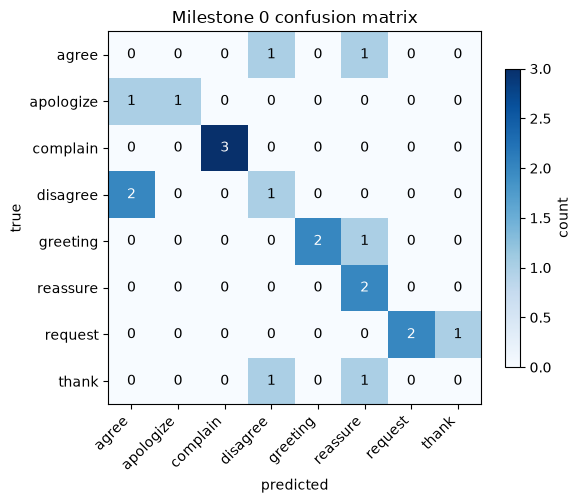

In [8]:
labels = sorted(test["intent"].unique())
cm = confusion_matrix(truth, preds, labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Milestone 0 confusion matrix")
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()


## Look at the mistakes

Reading the actual sentences the model got wrong is where real understanding starts — more useful than
any single number above.


In [9]:
results_df = pd.DataFrame({"text": test["text"], "true": truth, "predicted": preds})

RESULTS_DIR.mkdir(exist_ok=True)
out_path = RESULTS_DIR / "milestone0_predictions.csv"
results_df.to_csv(out_path, index=False)
print(f"Saved every test prediction to {out_path.relative_to(PROJECT_ROOT)}")

mistakes = results_df[results_df["true"] != results_df["predicted"]]
print(f"\n{len(mistakes)} of {len(results_df)} test sentences were misclassified:")
mistakes


Saved every test prediction to results\milestone0_predictions.csv

9 of 20 test sentences were misclassified:


,text,true,predicted
42,"Agreed, let's go with your idea.",agree,disagree
81,I'd like you to double-check the numbers.,request,thank
28,"That's on me, I'm sorry.",apologize,agree
16,"Cheers, you really saved me there.",thank,disagree
45,"Fair enough, I'll go along with it.",agree,reassure
52,That doesn't sound right to me.,disagree,agree
54,"Sorry, but I can't agree with that.",disagree,agree
13,I really appreciate you doing this.,thank,reassure
9,"Hello there, take a seat.",greeting,reassure


## Exercises

1. **Predict before running:** the setup cell used `ngram_range=(1, 2)` (single words + word pairs). Change
   it to `ngram_range=(1, 1)` (single words only) in the scaffold cell below. Do you expect accuracy to go
   up, down, or stay about the same? Run it and check.
2. Change `random_state=42` to a different number in the Step 2 split cell above, rerun Steps 2-4, and watch
   how much accuracy moves. What does that tell you about trusting a single score from a 96-row dataset?


In [10]:
# Exercise 1 scaffold: retrain with unigrams only (ngram_range=(1, 1)) and compare accuracy.
model_unigram = Pipeline(
    steps=[
        ("tfidf", TfidfVectorizer(ngram_range=(1, 1), min_df=1)),
        ("clf", LogisticRegression(max_iter=1000)),
    ]
)
model_unigram.fit(train["text"], train["intent"])
preds_unigram = model_unigram.predict(test["text"])
acc_unigram = accuracy_score(truth, preds_unigram)

print(f"Unigrams + bigrams accuracy : {acc:.3f}")
print(f"Unigrams only accuracy      : {acc_unigram:.3f}")


Unigrams + bigrams accuracy : 0.550
Unigrams only accuracy      : 0.550


## Pitfalls and extensions

**Common mistake:** judging the model only by accuracy. Look back at the per-class report above — some
intents (like `agree` or `thank`) can score 0 while accuracy still looks like "about half right," because
accuracy hides which specific classes are failing. Always check macro-F1 and the per-class report together.

**Extension:** once you're ready for Milestone 1, install the heavier libraries
(`pip install torch transformers datasets accelerate`) and try
`python ../src/train_text_only.py --model transformer` to fine-tune a small pretrained transformer
(DistilBERT) instead of TF-IDF + Logistic Regression, then compare its accuracy/macro-F1 to this notebook's.
